This compulsory assignment focuses on training, fine-tuning, and evaluating a Random Forest classifier on the MNIST dataset of handwritten digits.

## Workflow
1. Import the required libraries
2. Load the dataset
3. Inspect and understand the data
4. Prepare the data for training
5. Train and fine-tune the Random Forest classifier
6. Evaluate the final model on the test set

## 1. Import the required libraries

In [59]:
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay, classification_report
import numpy as np
import matplotlib.pyplot as plt
import optuna

## 2. Load the dataset

In [5]:
X, y = fetch_openml('mnist_784', version=1, return_X_y=True, as_frame=False)

## 3. Inspect and understand the data

- Check Shape of features and labels
- Check Target labels
- Convert labels dtype from object to integer
- Check class distribution
- Check for missing values
- Check the pixel value range
- Visualize a few samples

### Check Shape of features and labels

In [6]:
print("X shape:", X.shape)
print("y shape:", y.shape)
print("X dtype:", X.dtype)
print("y dtype:", y.dtype)
print(type(X), type(y))

X shape: (70000, 784)
y shape: (70000,)
X dtype: int64
y dtype: object
<class 'numpy.ndarray'> <class 'numpy.ndarray'>


### Check target labels

In [7]:
print("Unique labels:", np.unique(y))

Unique labels: ['0' '1' '2' '3' '4' '5' '6' '7' '8' '9']


### Convert labels dtype from object to integer (data cleaning)

In [8]:
y = y.astype(int)
print("Unique labels:", np.unique(y))

Unique labels: [0 1 2 3 4 5 6 7 8 9]


### Check class distribution

In [9]:
unique, counts = np.unique(y, return_counts=True)
for label, count in zip(unique, counts):
    print(f"Digit {label}: {count}")

Digit 0: 6903
Digit 1: 7877
Digit 2: 6990
Digit 3: 7141
Digit 4: 6824
Digit 5: 6313
Digit 6: 6876
Digit 7: 7293
Digit 8: 6825
Digit 9: 6958


### Check for missing values

In [10]:
print("Missing values in X:", np.isnan(X).sum())
print("Missing values in y:", np.isnan(y).sum())

Missing values in X: 0
Missing values in y: 0


### Check the pixel value range

In [11]:
print("Minimum pixel value:", X.min())
print("Maximum pixel value:", X.max())
print("Mean pixel value:", X.mean())

Minimum pixel value: 0
Maximum pixel value: 255
Mean pixel value: 33.385964741253645


### Visualize a few samples

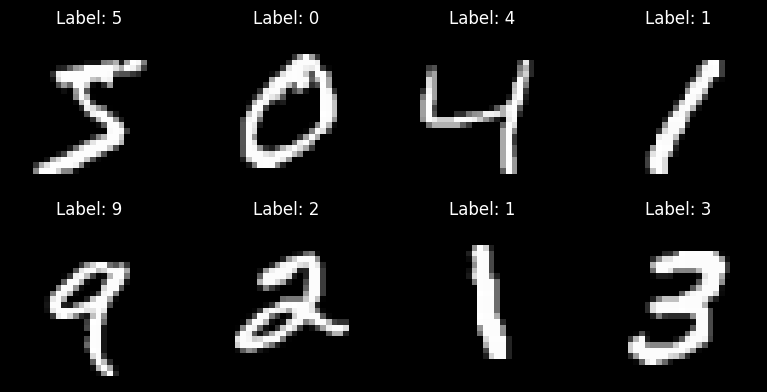

In [12]:
plt.figure(figsize=(8, 4))
for i in range(8):
    plt.subplot(2, 4, i + 1)
    plt.imshow(X[i].reshape(28, 28), cmap="gray")
    plt.title(f"Label: {y[i]}")
    plt.axis("off")
plt.tight_layout()
plt.show()

### Results

The inspection confirmed that the **MNIST** dataset contains **70,000 images**, with each image represented by **784 features**. This corresponds to images of size **28 × 28 pixels**, resulting in **784 pixel values** per sample. The target variable contains **70,000 labels**, representing the digit classes **0 to 9**.

The feature values range from **0 to 255**, where **0 corresponds to black** and 2**55 corresponds to white**, with intermediate values representing shades of gray. This is consistent with grayscale image data.

No missing values were detected in the feature matrix. In addition, the class distribution was found to be reasonably balanced across all ten digit classes, indicating that the dataset is suitable for a classification task.

Since the target labels were initially loaded as objects, they were converted to integers before proceeding to the data preparation stage.




## 4. Prepare the data for training

### Splitting the dataset


In [13]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [14]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (56000, 784)
X_test: (14000, 784)
y_train: (56000,)
y_test: (14000,)


### Results
Since the target labels had already been converted from **strings** to **integers** in the previous step, and the earlier inspection did not reveal any additional cleaning requirements, the main data preparation step was to split the dataset into **training** and **test** sets.

An **80/20 split** was applied, with 80% of the data used for training and 20% reserved for final testing. **Stratified sampling** was used to preserve the class distribution across both sets.

No **feature scaling** was applied, as **Random Forest** is a **tree-based algorithm** and does not generally require scaled input features.

## 5. Train and fine-tune the Random Forest classifier
- Hyperparameter optimization framework (Optuna)
- Evaluating final param combination, score and number of trials
- Train the final model with the params


### Hyperparameter optimization framework (Optuna)

In [26]:
def objective(trial):
    model = RandomForestClassifier(
        n_estimators=trial.suggest_int("n_estimators", 100, 500, step=100),
        max_depth=trial.suggest_categorical("max_depth", [10, 20, 30, None]),
        max_leaf_nodes=trial.suggest_categorical("max_leaf_nodes", [None, 300, 600, 1000]),
        min_samples_split=trial.suggest_int("min_samples_split", 2, 10),
        min_samples_leaf=trial.suggest_int("min_samples_leaf", 1, 4),
        max_features=trial.suggest_categorical("max_features", ["sqrt", "log2"]),
        random_state=42,
        n_jobs=1
    )

    score = cross_val_score(
        model,
        X_train,
        y_train,
        cv=3,
        scoring="accuracy",
        n_jobs=-1
    ).mean()

    return score

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=20)

[I 2026-03-16 15:52:17,530] A new study created in memory with name: no-name-6590c81e-ce06-452a-a89a-5f5d9141beb6
[I 2026-03-16 15:52:29,843] Trial 0 finished with value: 0.9366071536587434 and parameters: {'n_estimators': 300, 'max_depth': None, 'max_leaf_nodes': 300, 'min_samples_split': 8, 'min_samples_leaf': 4, 'max_features': 'log2'}. Best is trial 0 with value: 0.9366071536587434.
[I 2026-03-16 15:52:41,897] Trial 1 finished with value: 0.9365714467073211 and parameters: {'n_estimators': 300, 'max_depth': 20, 'max_leaf_nodes': 300, 'min_samples_split': 8, 'min_samples_leaf': 2, 'max_features': 'log2'}. Best is trial 0 with value: 0.9366071536587434.
[I 2026-03-16 15:52:53,940] Trial 2 finished with value: 0.9366607336971965 and parameters: {'n_estimators': 300, 'max_depth': None, 'max_leaf_nodes': 300, 'min_samples_split': 2, 'min_samples_leaf': 3, 'max_features': 'log2'}. Best is trial 2 with value: 0.9366607336971965.
[I 2026-03-16 15:53:23,147] Trial 3 finished with value: 0.9

### Evaluating final param combination, score and number of trials

In [35]:
print("Number of finished trials:", len(study.trials))
print("Best score:", study.best_value)
print("Best params:", study.best_params)

Number of finished trials: 20
Best score: 0.9677678912428078
Best params: {'n_estimators': 400, 'max_depth': None, 'max_leaf_nodes': None, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt'}


### Train the final model with the params

In [37]:
best_model = RandomForestClassifier(
    **study.best_params,
    random_state=42,
    n_jobs=-1
)

best_model.fit(X_train, y_train)

y_pred = best_model.predict(X_test)


### Results
**Optuna**, which is a **hyperparameter optimization framework**, was used to fine-tune the **RandomForestClassifier** by optimizing the **mean cross-validation accuracy** on the training set. A total of **20 trials** was performed.

The best **cross-validation score** obtained during tuning was **0.9678**, corresponding to an average validation accuracy of approximately **96.78%** across the 3 cross-validation folds.

The best hyperparameters found by Optuna was:
- **n_estimators** = 400
- **max_depth** = None
- **max_leaf_nodes** = None
- **min_samples_split** = 2
- **min_samples_leaf** = 1
- **max_features** = 'sqrt'

These results suggest that the model performed best when the forest contained a relatively large number of trees and when the individual trees were allowed to grow without restrictive limits on depth or leaf nodes.


## 6. Evaluate the final model on the test set

### Test accuracy & Classification report

In [49]:
print("Test accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification report:\n", classification_report(y_test, y_pred))

Test accuracy: 0.9680714285714286

Classification report:
               precision    recall  f1-score   support

           0       0.97      0.99      0.98      1381
           1       0.99      0.98      0.99      1575
           2       0.96      0.97      0.96      1398
           3       0.96      0.96      0.96      1428
           4       0.97      0.96      0.97      1365
           5       0.97      0.96      0.96      1263
           6       0.97      0.98      0.98      1375
           7       0.97      0.97      0.97      1459
           8       0.96      0.96      0.96      1365
           9       0.94      0.95      0.94      1391

    accuracy                           0.97     14000
   macro avg       0.97      0.97      0.97     14000
weighted avg       0.97      0.97      0.97     14000



### Confusion Matrix

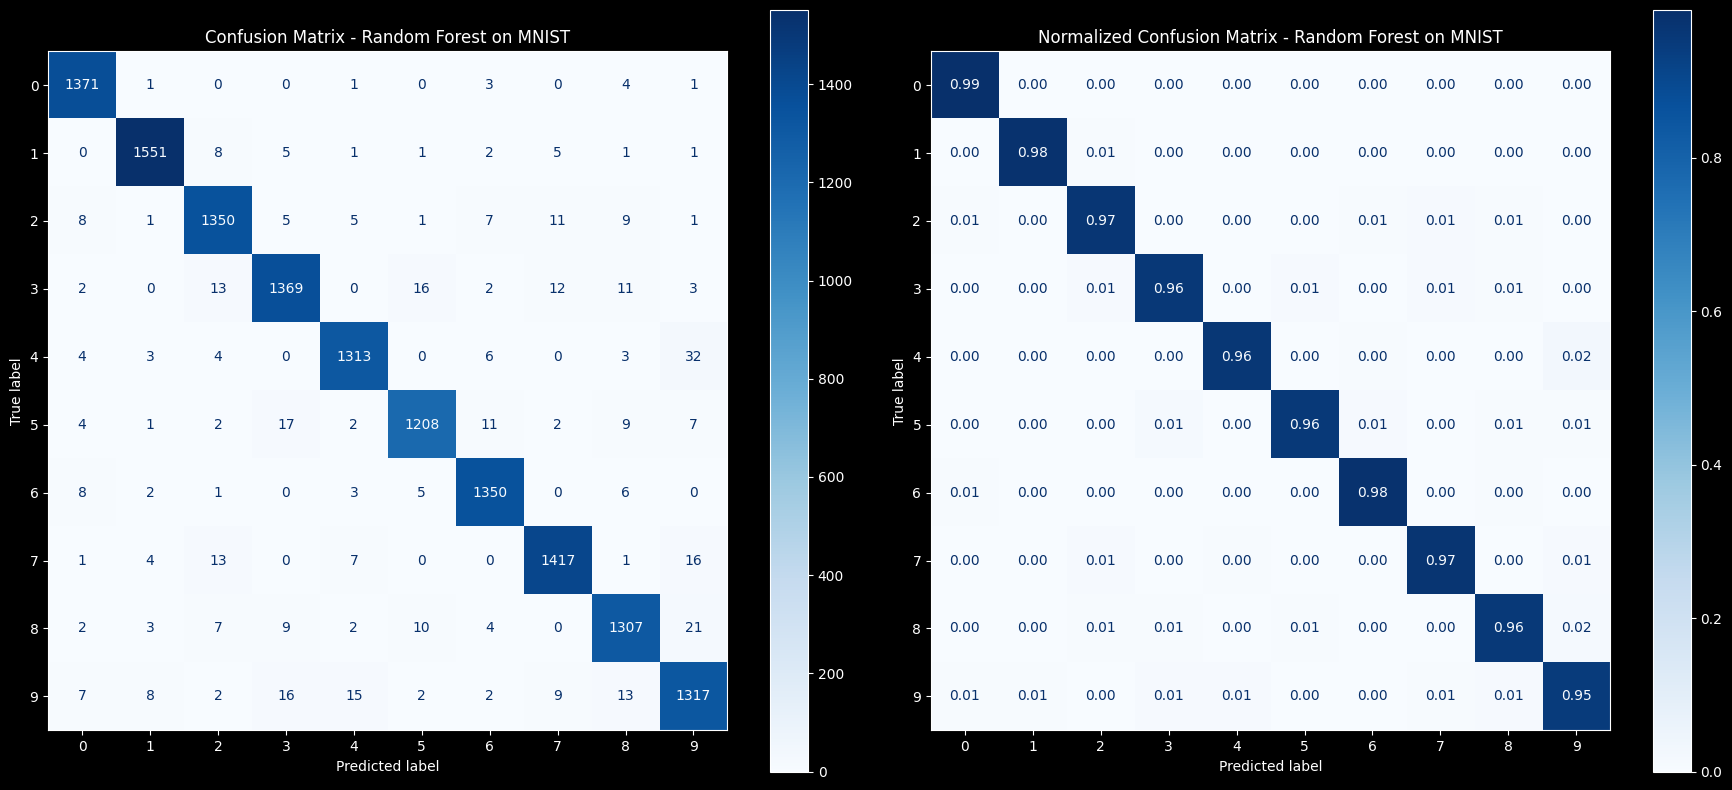

In [62]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Regular confusion matrix
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    cmap="Blues",
    values_format="d",
    ax=axes[0]
)
axes[0].set_title("Confusion Matrix - Random Forest on MNIST")

# Normalized confusion matrix
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    cmap="Blues",
    normalize="true",
    values_format=".2f",
    ax=axes[1]
)
axes[1].set_title("Normalized Confusion Matrix - Random Forest on MNIST")

plt.tight_layout()
plt.show()

### Results

The final Random Forest classifier achieved a **test accuracy of 96.81%**, meaning that it correctly classified approximately **97%** of the handwritten digit images in the test set.

The classification report indicates strong and consistent performance across all ten digit classes. Most **precision, recall, and F1-scores fall within the range of 0.96 to 0.99**, showing that the model performs well both overall and at the class level.

This interpretation is further supported by the confusion matrices. In both the regular and normalized confusion matrices, the **largest values are concentrated along the diagonal,** which indicates that the majority of test samples were classified correctly.

The normalized confusion matrix shows that the model **correctly classified approximately 95% to 99% of the samples in each digit class**. The strongest performance was observed for digits such as **0, 1, and 6,** while slightly lower, though still strong, performance was observed for digits such as **9, 3, 4, 5, and 8.**

Overall, the final evaluation indicates that the Random Forest classifier **generalized well** to unseen test data and achieved s**trong classification performance** on the **MNIST dataset.**